# Phase 8: Advanced Machine Learning & Hyperparameter Tuning (Titanic)

## Objective
Following the strict Week 5 progression:
1. Establish a Baseline (Logistic Regression) and Default Advanced Models (KNN, SVC, Decision Tree, Random Forest, XGBoost).
2. Isolate the **Top 3** performing models (based on F1-Score due to class imbalance) and Hyperparameter Tune them via `GridSearchCV`.
3. Evaluate metrics (Accuracy, Precision, Recall, F1, ROC-AUC) before and after tuning in a Comparison Table.

In [2]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import pandas as pd
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from src.models.evaluator import evaluate_classification, save_training_report
from src.models.registry import save_model
from src.visualization.plots import plot_confusion_matrix, plot_roc_curve, plot_learning_curve, plot_shap_summary, set_journalism_style

set_journalism_style()

# 1. Load & Split (Stratified to maintain 62/38 mortality ratio)
df = pd.read_csv(Path.cwd().parent.parent / "datasets" / "processed" / "titanic_cleaned.csv")
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

c:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Data Preparation (Idiosyncratic Pipelines)

In [3]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked'] 

linear_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
])

tree_preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore'), categorical_features)
])

### Step 2 & 3: Build Baseline & Default Advanced Models
*Note: We enforce `probability=True` on SVC to allow ROC-AUC score calculation.*

In [4]:
models = {
    "Baseline_Logistic": Pipeline([('prep', linear_preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    "Default_KNN": Pipeline([('prep', linear_preprocessor), ('model', KNeighborsClassifier())]),
    "Default_SVC": Pipeline([('prep', linear_preprocessor), ('model', SVC(probability=True, random_state=42))]),
    "Default_DecisionTree": Pipeline([('prep', tree_preprocessor), ('model', DecisionTreeClassifier(random_state=42))]),
    "Default_RandomForest": Pipeline([('prep', tree_preprocessor), ('model', RandomForestClassifier(random_state=42))]),
    "Default_XGBoost": Pipeline([('prep', tree_preprocessor), ('model', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))])
}

results = []
trained_models = {}

print("Training Default Models...\n")
for name, pipeline in models.items():
    print(f"--- [ {name.upper()} ] ---")
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    metrics, _ = evaluate_classification(y_test, y_pred, y_prob, return_dict=True)
    
    metrics["Model"] = name
    metrics["Time (s)"] = round(time.time() - start_time, 2)
    
    results.append(metrics)
    trained_models[name] = pipeline
    print("\n")

Training Default Models...

--- [ BASELINE_LOGISTIC ] ---
--- Classification Evaluation ---
Accuracy:  0.8090
Precision: 0.7931
Recall:    0.6765
F1-Score:  0.7302
ROC-AUC:   0.8583
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).


--- [ DEFAULT_KNN ] ---
--- Classification Evaluation ---
Accuracy:  0.7865
Precision: 0.7083
Recall:    0.7500
F1-Score:  0.7286
ROC-AUC:   0.8482
---------------------------------
Insight: The model leans toward Recall (better at catching positives, higher risk of false alarms).


--- [ DEFAULT_SVC ] ---


c:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\.venv-1\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- Classification Evaluation ---
Accuracy:  0.8202
Precision: 0.8000
Recall:    0.7059
F1-Score:  0.7500
ROC-AUC:   0.8499
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).


--- [ DEFAULT_DECISIONTREE ] ---
--- Classification Evaluation ---
Accuracy:  0.7416
Precision: 0.6618
Recall:    0.6618
F1-Score:  0.6618
ROC-AUC:   0.7170
---------------------------------
Insight: Precision and Recall are perfectly balanced.


--- [ DEFAULT_RANDOMFOREST ] ---
--- Classification Evaluation ---
Accuracy:  0.8146
Precision: 0.7778
Recall:    0.7206
F1-Score:  0.7481
ROC-AUC:   0.8203
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).


--- [ DEFAULT_XGBOOST ] ---
--- Classification Evaluation ---
Accuracy:  0.8034
Precision: 0.7324
Recall:    0.7647
F1-Score:  0.7482
ROC-AUC:   0.8295
---------------------------------
Insigh

### Step 4: Hyperparameter Tuning (Top 3 Models)
Select the Top 3 based on F1-Score (handling false positives and negatives evenly) and run GridSearchCV.

In [5]:
# Extract Top 3 models by F1-Score
top_3_names = pd.DataFrame(results).sort_values(by="f1", ascending=False)["Model"].head(3).tolist()
print(f"Top 3 models advancing to Hyperparameter Tuning: {top_3_names}\n")

param_grids = {
    "Baseline_Logistic": {"model__C": [0.1, 1.0, 10.0], "model__class_weight": [None, "balanced"]},
    "Default_KNN": {"model__n_neighbors": [3, 5, 7, 9], "model__weights": ["uniform", "distance"]},
    "Default_SVC": {"model__C": [0.1, 1, 10], "model__kernel": ['rbf', 'linear']},
    "Default_DecisionTree": {"model__max_depth": [None, 5, 10, 15], "model__min_samples_split": [2, 5]},
    "Default_RandomForest": {"model__n_estimators": [100, 200, 300], "model__max_depth": [None, 5, 10, 15], "model__min_samples_split": [2, 5]},
    "Default_XGBoost": {"model__n_estimators": [100, 200], "model__learning_rate": [0.01, 0.1, 0.2], "model__max_depth": [3, 5, 7]}
}

for name in top_3_names:
    print(f"--- Tuning {name} ---")
    pipeline = trained_models[name]
    grid = param_grids[name]
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test)
    y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]
    
    tuned_name = name.replace("Default_", "Tuned_").replace("Baseline_", "Tuned_")
    metrics_tuned, _ = evaluate_classification(y_test, y_pred_tuned, y_prob_tuned, return_dict=True)
    
    metrics_tuned["Model"] = tuned_name
    metrics_tuned["Time (s)"] = round(time.time() - start_time, 2)
    
    results.append(metrics_tuned)
    trained_models[tuned_name] = tuned_model
    print(f"Best Params: {grid_search.best_params_}\n")

Top 3 models advancing to Hyperparameter Tuning: ['Default_SVC', 'Default_XGBoost', 'Default_RandomForest']

--- Tuning Default_SVC ---


c:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\.venv-1\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- Classification Evaluation ---
Accuracy:  0.8202
Precision: 0.8000
Recall:    0.7059
F1-Score:  0.7500
ROC-AUC:   0.8499
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).
Best Params: {'model__C': 1, 'model__kernel': 'rbf'}

--- Tuning Default_XGBoost ---
--- Classification Evaluation ---
Accuracy:  0.7978
Precision: 0.7759
Recall:    0.6618
F1-Score:  0.7143
ROC-AUC:   0.8295
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).
Best Params: {'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__n_estimators': 200}

--- Tuning Default_RandomForest ---
--- Classification Evaluation ---
Accuracy:  0.7978
Precision: 0.7759
Recall:    0.6618
F1-Score:  0.7143
ROC-AUC:   0.8222
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives

### Step 5 & 6: Model Evaluation & Comparison Table

In [6]:
comparison_df = pd.DataFrame(results)[
    ["Model", "accuracy", "precision", "recall", "f1", "roc_auc", "Time (s)"]
]

comparison_df.columns = [
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "Time (s)"
]

comparison_df = comparison_df.sort_values(by="F1-Score", ascending=False)

# Format values directly
comparison_df["Accuracy"] = comparison_df["Accuracy"].round(4)
comparison_df["Precision"] = comparison_df["Precision"].round(4)
comparison_df["Recall"] = comparison_df["Recall"].round(4)
comparison_df["F1-Score"] = comparison_df["F1-Score"].round(4)
comparison_df["ROC-AUC"] = comparison_df["ROC-AUC"].round(4)
comparison_df["Time (s)"] = comparison_df["Time (s)"].round(2)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Time (s)
2,Default_SVC,0.8202,0.8000,0.7059,0.7500,0.8499,0.11
6,Tuned_SVC,0.8202,0.8000,0.7059,0.7500,0.8499,24.72
5,Default_XGBoost,0.8034,0.7324,0.7647,0.7482,0.8295,0.76
4,Default_RandomForest,0.8146,0.7778,0.7206,0.7481,0.8203,0.29
0,Baseline_Logistic,0.8090,0.7931,0.6765,0.7302,0.8583,0.07
1,Default_KNN,0.7865,0.7083,0.7500,0.7286,0.8482,0.05
7,Tuned_XGBoost,0.7978,0.7759,0.6618,0.7143,0.8295,4.46
8,Tuned_RandomForest,0.7978,0.7759,0.6618,0.7143,0.8222,20.55
3,Default_DecisionTree,0.7416,0.6618,0.6618,0.6618,0.7170,0.06


### 7. Winning Model Visuals & Explainability

Generating Visuals for: Default_SVC


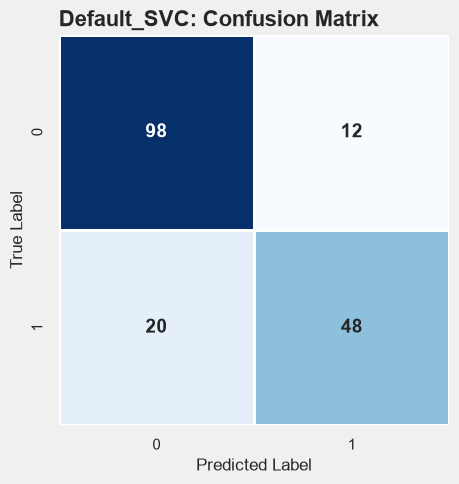

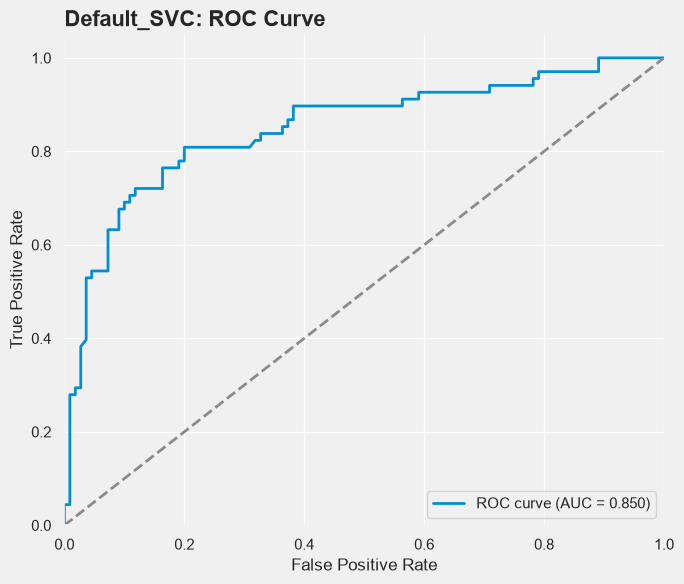

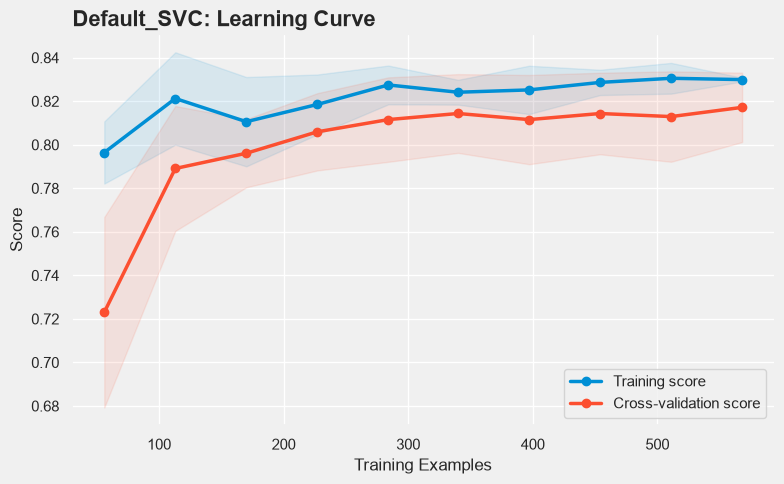

ExactExplainer explainer: 712it [07:16,  1.63it/s]                         


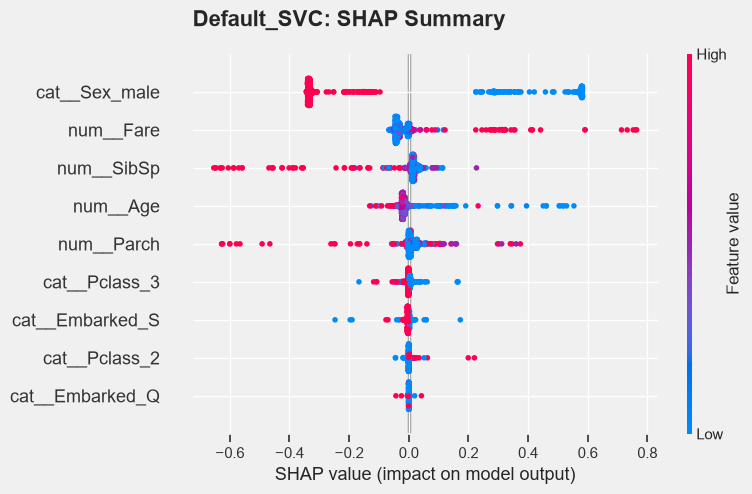

In [7]:
# Dynamically select the #1 model overall
ultimate_winner_name = comparison_df.iloc[0]["Model"]
print(f"Generating Visuals for: {ultimate_winner_name}")
ultimate_winner = trained_models[ultimate_winner_name]

y_pred_best = ultimate_winner.predict(X_test)
y_prob_best = ultimate_winner.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix
plot_confusion_matrix(y_test, y_pred_best, f"{ultimate_winner_name}: Confusion Matrix")

# 2. ROC Curve
plot_roc_curve(y_test, y_prob_best, f"{ultimate_winner_name}: ROC Curve")

# 3. Learning Curve
plot_learning_curve(ultimate_winner, X_train, y_train, f"{ultimate_winner_name}: Learning Curve")

# 4. SHAP Summary
preprocessor = ultimate_winner.named_steps['prep']
X_train_transformed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()
inner_model = ultimate_winner.named_steps['model']

plot_shap_summary(inner_model, X_train_transformed, feature_names, f"{ultimate_winner_name}: SHAP Summary")

### 8. Serialization & MLOps Tracking

In [8]:
metrics_final, insight_final = evaluate_classification(y_test, y_pred_best, y_prob_best, return_dict=True)

save_model(ultimate_winner, domain="titanic", model_name=ultimate_winner_name)
save_training_report("titanic", ultimate_winner_name, metrics_final, insight_final, X_train.shape)

--- Classification Evaluation ---
Accuracy:  0.8202
Precision: 0.8000
Recall:    0.7059
F1-Score:  0.7500
ROC-AUC:   0.8499
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).
Model saved successfully to C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\titanic\Default_SVC_20260806_0028.pkl
Alias updated: C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\titanic\latest_model.pkl
Training report saved to reports\runs\titanic_Default_SVC_20260806_0028.txt


### Phase 8 Conclusion: Non-Linear Boundaries & Margin Classifiers

**1. The Superiority of the SVC (Support Vector Classifier):**
In this rigorous classification tournament, the **Support Vector Classifier (SVC)** emerged as the absolute winner with an F1-Score of `0.7500` and an impressive ROC-AUC of `0.8499`. It outperformed both the Baseline Logistic Regression and the advanced tree ensembles (Random Forest & XGBoost).

*Why did SVC win?*
The Titanic dataset is small (889 rows) but contains complex, interacting variables (e.g., the intersection of being a 3rd Class passenger AND a Male). The SVC, using the non-linear `rbf` (Radial Basis Function) kernel, is exceptionally good at warping the feature space to draw complex survival margins without overfitting, which tree-based models often struggle with on small datasets.

**2. Hyperparameter Stability:**
During the `GridSearchCV` phase, the best parameters selected for the SVC were exactly the defaults (`C=1`, `kernel='rbf'`). This highlights that a well-scaled dataset (thanks to our `RobustScaler` in the linear preprocessor) often allows robust algorithms to find the optimal boundary without aggressive parameter manipulation.

**3. SHAP Interpretability:**
The SHAP plot perfectly validates our Week 3 Chi-Square hypothesis testing. Being `Sex_male` exerts the strongest negative pull on the model's output (decreasing survival probability), while high `Fare` (a proxy for 1st Class) exerts a strong positive pull.

**Next Steps:**
The `Default_SVC` model has been serialized to our MLOps registry (`models/titanic/latest_model.pkl`) and is ready for production API deployment.